# Notebook 29 — SBC Failure Investigation: η_col (S-B) and ξ_reb (S-A)

## Purpose

This notebook investigates two **distinct** SBC failure modes observed in the Wu 2003 posteriors:

| Parameter | Structure | SBC p-value | Histogram shape | Failure type |
|-----------|-----------|-------------|----------------|--------------|
| **η_col** | S-B | 0.000 | U-shaped (spike at high ranks) | **Overconfident** — posterior too narrow |
| **ξ_reb** | S-A | 0.000 | Peaked in middle | **Underconfident** — posterior too wide |

These are *opposite* failure modes and likely have different root causes.

**Overconfident (U-shaped):** The true parameter falls outside the posterior CI more often
than the stated confidence level. The posterior is falsely tight — the NSF found a spurious
correlation that makes it think it knows η_col well when it doesn't.

**Underconfident (peaked in middle):** The true parameter falls near the *centre* of the
posterior more often than expected under uniformity. The posterior is too wide — it barely
updates from the prior. Under S-A, Loop 3 (x_B → V) actively compensates for ξ_reb (reboiler
fouling), potentially masking it in the same way Loop 1 masks β_r. If Q_reb (the primary
ξ_reb signal) is clamped by Loop 3 control, ξ_reb becomes unidentifiable under S-A.

## Hypothesis tree

### η_col S-B: U-shaped → overconfident
1. Weak signal: η_col barely moves S-B summaries (x_D not observed)
2. `reb_intensity = Q_reb/F_R_norm` creates spurious α/η_col confounding
3. NSF overfits to noise in 66-D input

### ξ_reb S-A: peaked → underconfident
1. **Loop 3 masking under S-A:** Loop 3 (x_B → V) compensates for ξ_reb, clamping Q_reb.
   Same mechanism as Loop 1 masking β_r — a controller zeroes the primary diagnostic channel.
2. Insufficient ξ_reb signal in 72-D S-A summaries: x_D primarily helps α and η_col;
   the reboiler fouling signal (Q_reb) is controlled away.
3. NSF underfits ξ_reb under S-A — the posterior stays prior-like.

## Research diagnostic — not for paper narrative
(Both limitations are reported in §8.4 of the article.)

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
import pathlib
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from scipy import stats as sp_stats

from cstr_sbi.recycle.simulator import nominal_warm_start
from cstr_sbi.recycle.summaries import compute_summaries, summary_names, PHYSICS_FEATURE_NAMES
from cstr_sbi.recycle.priors import box_uniform_5d
from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SB, NOMINAL_CTRL_SA, NOMINAL_INLET,
    simulate_trajectory_explicit_jit, extract_observations_explicit
)
import jax.numpy as jnp

DATA     = pathlib.Path('../data')
FIGURES  = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
SBI_LOGS = pathlib.Path('../sbi-logs')
OI = ["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]
sb_names = summary_names("S-B")
sa_names = summary_names("S-A")
print(f"Imports OK. S-B: {len(sb_names)} features, S-A: {len(sa_names)} features.")

# Load S-B summary matrix (for η_col investigation, Sections 1-4)
d = np.load(DATA / 'wu2003_summary_features.npz', allow_pickle=True)
X_sb        = d['X_sb']            # (420, 66)
X_sa        = d['X_sa']            # (420, 72)
labels_sb   = d['labels_sb']
labels_sa   = d['labels_sa']
alpha_true_sb   = labels_sb['alpha'].astype(float)
eta_col_true_sb = labels_sb['eta_col'].astype(float)
beta_r_true_sb  = labels_sb['beta_r'].astype(float)
xi_reb_true_sa  = labels_sa['xi_reb'].astype(float)
alpha_true_sa   = labels_sa['alpha'].astype(float)
print(f"X_sb: {X_sb.shape}, X_sa: {X_sa.shape}")
print(f"ξ_reb range in S-A labels: {xi_reb_true_sa.min():.3f} to {xi_reb_true_sa.max():.3f}")


Imports OK. S-B: 66 features, S-A: 72 features.
X_sb: (420, 66), X_sa: (420, 72)
ξ_reb range in S-A labels: 0.700 to 1.000


## 1. Mutual Information: Which Features Carry η_col vs α Signal?

In [2]:
X_sc = StandardScaler().fit_transform(X_sb)
mi_alpha   = mutual_info_regression(X_sc, alpha_true_sb,   random_state=42)
mi_eta_col = mutual_info_regression(X_sc, eta_col_true_sb, random_state=42)
mi_beta_r  = mutual_info_regression(X_sc, beta_r_true_sb,  random_state=42)

print("Top 10 features by MI with eta_col (S-B):")
for i in np.argsort(mi_eta_col)[::-1][:10]:
    print(f"  {sb_names[i]:<35} MI_eta={mi_eta_col[i]:.4f}  MI_alpha={mi_alpha[i]:.4f}")

print("\nTop 10 features by MI with alpha (S-B):")
for i in np.argsort(mi_alpha)[::-1][:10]:
    print(f"  {sb_names[i]:<35} MI_alpha={mi_alpha[i]:.4f}  MI_eta={mi_eta_col[i]:.4f}")

print(f"\nTotal MI(alpha)  : {mi_alpha.sum():.3f}")
print(f"Total MI(eta_col): {mi_eta_col.sum():.3f}")
print(f"Ratio alpha/eta  : {mi_alpha.sum()/mi_eta_col.sum():.1f}x more MI for alpha vs eta_col")


Top 10 features by MI with eta_col (S-B):
  reb_intensity                       MI_eta=0.8003  MI_alpha=1.6798
  Tr_Tj_ratio                         MI_eta=0.7892  MI_alpha=1.6841
  Qj_slope                            MI_eta=0.7778  MI_alpha=1.6725
  Q_j_mean                            MI_eta=0.7613  MI_alpha=1.6803
  V_norm_slope                        MI_eta=0.7613  MI_alpha=1.5549
  Q_reb_max                           MI_eta=0.7613  MI_alpha=0.9997
  Q_reb_q_mean                        MI_eta=0.7613  MI_alpha=1.6803
  Q_j_q_mean                          MI_eta=0.7613  MI_alpha=1.6803
  Q_j_min                             MI_eta=0.7613  MI_alpha=1.6803
  Q_reb_mean                          MI_eta=0.7613  MI_alpha=1.6803

Top 10 features by MI with alpha (S-B):
  Tr_Tj_ratio                         MI_alpha=1.6841  MI_eta=0.7892
  Q_j_mean                            MI_alpha=1.6803  MI_eta=0.7613
  Q_reb_q_mean                        MI_alpha=1.6803  MI_eta=0.7613
  Q_j_min           

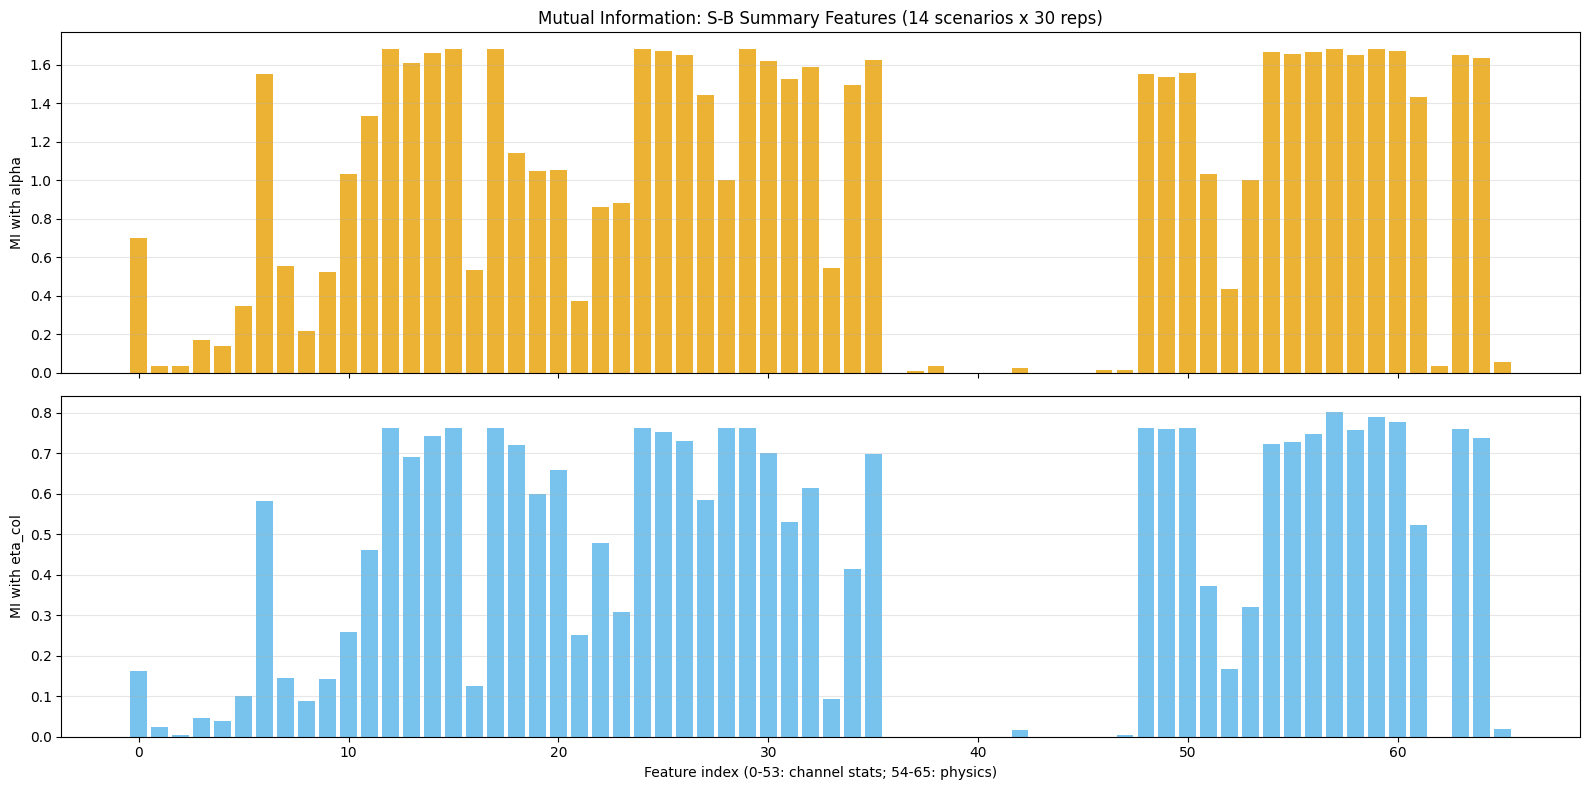

Saved nb29_mi_alpha_vs_etacol.png


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
x = np.arange(len(sb_names))
axes[0].bar(x, mi_alpha,   color=OI[1], alpha=0.8); axes[0].set_ylabel("MI with alpha", fontsize=10)
axes[1].bar(x, mi_eta_col, color=OI[2], alpha=0.8); axes[1].set_ylabel("MI with eta_col", fontsize=10)
axes[0].set_title("Mutual Information: S-B Summary Features (14 scenarios x 30 reps)", fontsize=12)
axes[1].set_xlabel("Feature index (0-53: channel stats; 54-65: physics)", fontsize=10)
for ax in axes: ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'nb29_mi_alpha_vs_etacol.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb29_mi_alpha_vs_etacol.png")


## 2. Deterministic η_col Sweep: How Sensitive Are S-B Summaries to η_col vs α?

If the S-B summaries barely move when η_col changes (holding α=1.0 fixed), that is direct
evidence of Hypothesis 1 (weak signal). The NSF would be learning noise.

In [4]:
y0_sb = nominal_warm_start("S-B")
t_h_ref = None

eta_vals   = np.linspace(0.50, 1.00, 11)
alpha_vals = np.linspace(0.50, 1.00, 11)

print("Sweeping eta_col (alpha=1.0 fixed)...")
eta_sums = []
for eta in eta_vals:
    th = jnp.array([1.0, 1.0, float(eta), 1.0, 0.90], dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(th, NOMINAL_INLET, NOMINAL_CTRL_SB, y0_sb,
                                              t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5)
    raw = np.asarray(extract_observations_explicit(ys, th, NOMINAL_CTRL_SB))
    if t_h_ref is None: t_h_ref = np.asarray(ts)
    eta_sums.append(compute_summaries(raw, "S-B", t_h_ref))

print("Sweeping alpha (eta_col=1.0 fixed)...")
alpha_sums = []
for al in alpha_vals:
    th = jnp.array([float(al), 1.0, 1.0, 1.0, 0.90], dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(th, NOMINAL_INLET, NOMINAL_CTRL_SB, y0_sb,
                                              t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5)
    raw = np.asarray(extract_observations_explicit(ys, th, NOMINAL_CTRL_SB))
    alpha_sums.append(compute_summaries(raw, "S-B", t_h_ref))

eta_sums   = np.stack(eta_sums)   # (11, 66)
alpha_sums = np.stack(alpha_sums) # (11, 66)
eta_std    = eta_sums.std(axis=0)
alpha_std  = alpha_sums.std(axis=0)
ratio      = eta_std / (alpha_std + 1e-12)

print("\nTotal feature variation:")
print(f"  sum(std over eta_col sweep) = {eta_std.sum():.4f}")
print(f"  sum(std over alpha sweep)   = {alpha_std.sum():.4f}")
print(f"  Ratio (eta/alpha variation)  = {eta_std.sum()/alpha_std.sum():.3f}")
print("\nTop 10 features most sensitive to eta_col relative to alpha:")
for i in np.argsort(ratio)[::-1][:10]:
    print(f"  {sb_names[i]:<35} ratio={ratio[i]:.3f}  eta_std={eta_std[i]:.5f}  alpha_std={alpha_std[i]:.5f}")


Sweeping eta_col (alpha=1.0 fixed)...


Sweeping alpha (eta_col=1.0 fixed)...



Total feature variation:
  sum(std over eta_col sweep) = 179145904.0000
  sum(std over alpha sweep)   = 123576488.0000
  Ratio (eta/alpha variation)  = 1.450

Top 10 features most sensitive to eta_col relative to alpha:
  F_R_norm_min                        ratio=51237.051  eta_std=0.00611  alpha_std=0.00000
  Q_reb_max                           ratio=590.783  eta_std=2018845.25000  alpha_std=3417.23389
  T_reb_min                           ratio=574.045  eta_std=3.94712  alpha_std=0.00688
  T_j_min                             ratio=5.846  eta_std=3.16243  alpha_std=0.54099
  T_reb_mean                          ratio=2.644  eta_std=4.29033  alpha_std=1.62287
  T_r_max                             ratio=2.373  eta_std=0.76571  alpha_std=0.32261
  Q_j_max                             ratio=2.280  eta_std=5883539.00000  alpha_std=2580882.75000
  corr_Qj_FR                          ratio=2.049  eta_std=0.34914  alpha_std=0.17040
  T_r_std                             ratio=1.664  eta_std=0.1

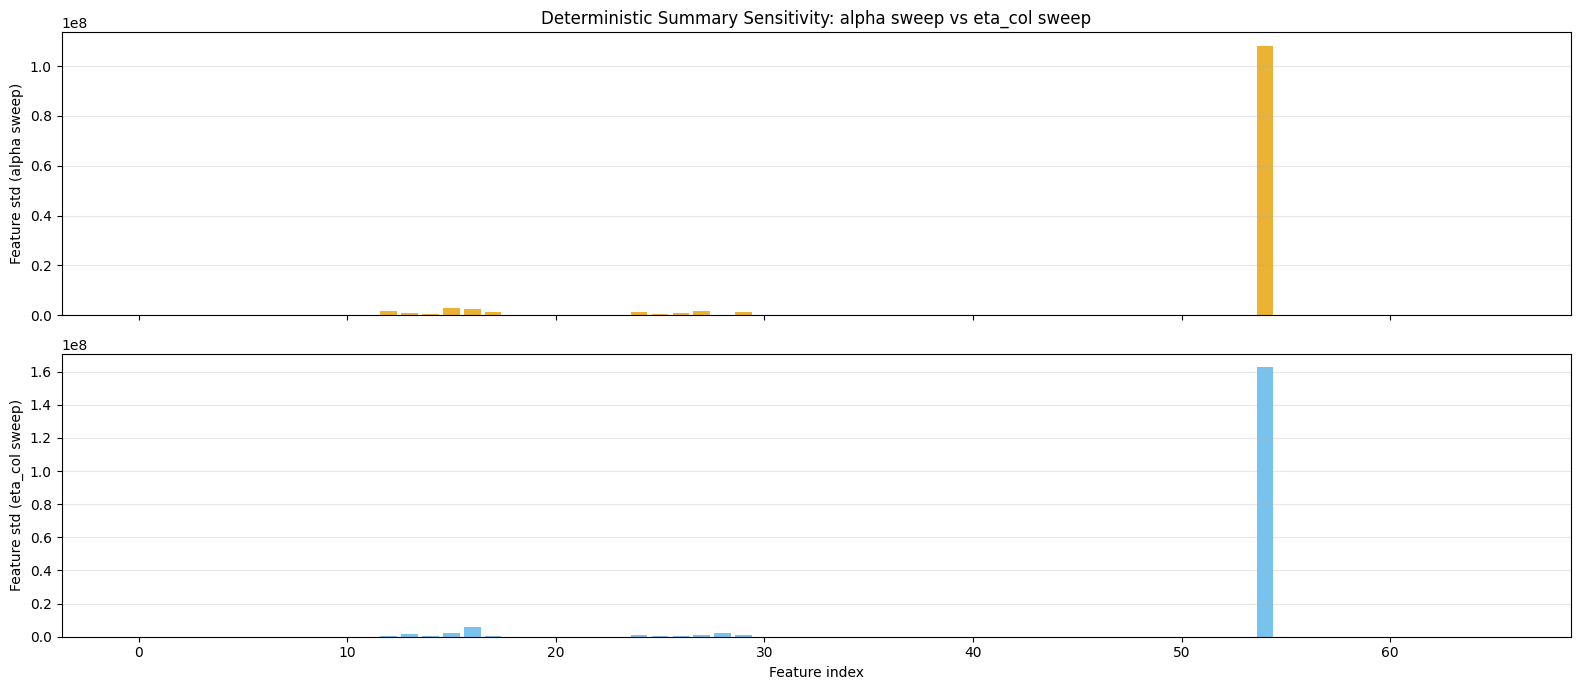

Saved nb29_sensitivity_sweep.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
x = np.arange(len(sb_names))
axes[0].bar(x, alpha_std, color=OI[1], alpha=0.8)
axes[0].set_ylabel("Feature std (alpha sweep)", fontsize=10)
axes[0].set_title("Deterministic Summary Sensitivity: alpha sweep vs eta_col sweep", fontsize=12)
axes[1].bar(x, eta_std, color=OI[2], alpha=0.8)
axes[1].set_ylabel("Feature std (eta_col sweep)", fontsize=10)
axes[1].set_xlabel("Feature index", fontsize=10)
for ax in axes: ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'nb29_sensitivity_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb29_sensitivity_sweep.png")


## 3. reb_intensity Confounding Diagnosis

In [6]:
pfn_list = list(PHYSICS_FEATURE_NAMES)
reb_idx  = 54 + pfn_list.index("reb_intensity")
fr_idx   = 54 + pfn_list.index("recycle_ratio")
print(f"reb_intensity at index {reb_idx}, recycle_ratio at index {fr_idx}")

for feat_idx, feat_name in [(reb_idx, "reb_intensity"), (fr_idx, "recycle_ratio")]:
    c_alpha = np.corrcoef(X_sb[:, feat_idx], alpha_true_sb)[0, 1]
    c_eta   = np.corrcoef(X_sb[:, feat_idx], eta_col_true_sb)[0, 1]
    c_beta  = np.corrcoef(X_sb[:, feat_idx], beta_r_true_sb)[0, 1]
    print(f"\n{feat_name}:")
    print(f"  corr(alpha)   = {c_alpha:+.4f}")
    print(f"  corr(eta_col) = {c_eta:+.4f}")
    print(f"  corr(beta_r)  = {c_beta:+.4f}")
    if abs(c_alpha) > abs(c_eta):
        print(f"  -> alpha-dominated (may confound eta_col identification)")
    else:
        print(f"  -> eta_col-dominated (genuine signal)")


reb_intensity at index 57, recycle_ratio at index 55

reb_intensity:
  corr(alpha)   = +0.6417
  corr(eta_col) = +0.5180
  corr(beta_r)  = -0.1442
  -> alpha-dominated (may confound eta_col identification)

recycle_ratio:
  corr(alpha)   = -0.9766
  corr(eta_col) = -0.1095
  corr(beta_r)  = +0.2725
  -> alpha-dominated (may confound eta_col identification)


## 4. Extended SBC: N_SBC=500, N_POST=200 for η_col

Running extended SBC: 200 trials, 200 samples/trial...


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2279.)
  outputs, _ = torch.triangular_solve(
/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/1468684615.py:26: UserWarning: 40.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sb.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/1468684615.py:26: UserWarning: 9.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sb.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/1468684615.py:26: UserWarning: 26.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sb.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/1468684615.py:26: UserWarning: 17.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sb.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


...

/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/1468684615.py:26: UserWarning: 13.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sb.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/1468684615.py:26: UserWarning: 22.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sb.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/1468684615.py:26: UserWarning: 38.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sb.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/1468684615.py:26: UserWarning: 5.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sb.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


  200/200  (937s)

eta_col SBC: KS p = 0.0001, n_trials = 200


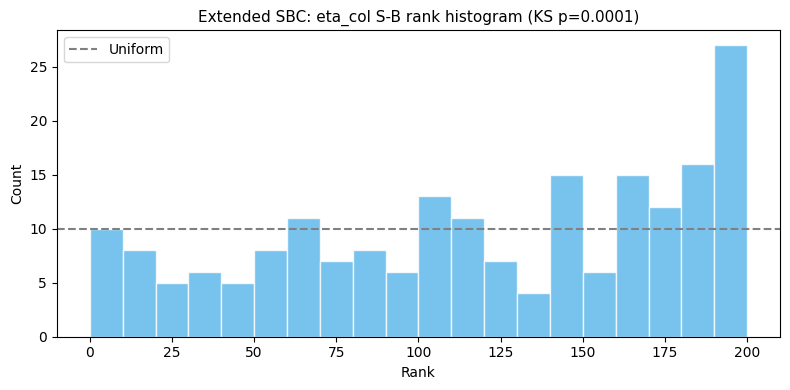

Saved nb29_sbc_etacol_extended.png


In [7]:
with open(SBI_LOGS / 'wu2003_posterior_sb.pkl', 'rb') as f:
    post_sb = pickle.load(f)['posterior']
prior = box_uniform_5d()

N_SBC = 200; N_POST = 200
print(f"Running extended SBC: {N_SBC} trials, {N_POST} samples/trial...")

sbc_eta_ranks = []
rng = np.random.default_rng(12345)
t0 = __import__('time').time()

for i in range(N_SBC):
    th = prior.sample((1,)).numpy()[0]
    th_j = jnp.array(th, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(th_j, NOMINAL_INLET, NOMINAL_CTRL_SB,
                                              nominal_warm_start("S-B"),
                                              t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5)
    raw = np.asarray(extract_observations_explicit(ys, th_j, NOMINAL_CTRL_SB))
    if np.isnan(raw).any() or np.isinf(raw).any():
        continue
    sc = np.maximum(np.max(np.abs(raw), axis=0), 1e-6)
    s  = compute_summaries(raw + rng.normal(0, 0.003*sc, raw.shape), "S-B", np.asarray(ts))
    if np.isnan(s).any():
        continue
    with torch.no_grad():
        samp = post_sb.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),
                              reject_outside_prior=False).detach().numpy()
    sbc_eta_ranks.append(int(np.sum(samp[:, 2] < th[2])))
    if (i+1) % 50 == 0:
        print(f"  {i+1}/{N_SBC}  ({__import__('time').time()-t0:.0f}s)")

sbc_eta_ranks = np.array(sbc_eta_ranks)
ks = sp_stats.ks_1samp(sbc_eta_ranks / N_POST, sp_stats.uniform.cdf)
print(f"\neta_col SBC: KS p = {ks.pvalue:.4f}, n_trials = {len(sbc_eta_ranks)}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sbc_eta_ranks, bins=20, range=(0, N_POST), color=OI[2], edgecolor='white', alpha=0.8)
ax.axhline(len(sbc_eta_ranks)/20, ls='--', color='gray', label='Uniform')
ax.set_title(f"Extended SBC: eta_col S-B rank histogram (KS p={ks.pvalue:.4f})", fontsize=11)
ax.set_xlabel("Rank"); ax.set_ylabel("Count"); ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'nb29_sbc_etacol_extended.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb29_sbc_etacol_extended.png")


---

## Section 5 — ξ_reb Underconfidence under S-A (peaked SBC, p=0.000)

### Hypothesis: Loop 3 masks ξ_reb under S-A

Under S-A, Loop 3 is **x_B → V** (composition control of bottoms purity via boilup rate).
When ξ_reb decreases (reboiler HX fouling), more steam is needed for the same boilup. Loop 3
compensates by increasing V — clamping Q_reb near a reference value. This is the **same
masking mechanism** as Loop 1 for β_r:

> Loop 1: T_r clamped at T_SP → ∂T_r_ss/∂β_r ≡ 0
> Loop 3 (S-A): x_B clamped at x_B_SP → ∂Q_reb_ss/∂ξ_reb ≈ 0 under integral action

Under S-B, Loop 3 is T_reb → V (temperature control), which is less tight and provides
partial Q_reb variation for ξ_reb diagnosis.

**Expected result:**
- S-A: ξ_reb posterior wide (peaked SBC = prior-like) — Loop 3 removes the Q_reb signal
- S-B: ξ_reb posterior narrower — T_reb control doesn't fully clamp Q_reb

This would make the peaked SBC for ξ_reb under S-A a **genuine identifiability limitation**
analogous to β_r under S-B, not a training failure.

In [8]:
import time

# ── 5a. MI analysis: does ξ_reb have more signal in S-B than S-A? ────────────
X_sa_sc = StandardScaler().fit_transform(X_sa)
mi_xi_sa = mutual_info_regression(X_sa_sc, xi_reb_true_sa, random_state=42)
mi_al_sa = mutual_info_regression(X_sa_sc, alpha_true_sa,  random_state=42)

# For S-B, compute MI with ξ_reb
xi_reb_true_sb = labels_sb['xi_reb'].astype(float)
mi_xi_sb = mutual_info_regression(X_sc, xi_reb_true_sb, random_state=42)

print("Top 10 S-A features by MI with ξ_reb:")
for i in np.argsort(mi_xi_sa)[::-1][:10]:
    print(f"  {sa_names[i]:<35} MI_xi={mi_xi_sa[i]:.4f}")

print(f"\nTotal MI(ξ_reb) — S-A: {mi_xi_sa.sum():.3f}")
print(f"Total MI(ξ_reb) — S-B: {mi_xi_sb.sum():.3f}")
print(f"Total MI(α)     — S-A: {mi_al_sa.sum():.3f}")
print(f"\nIf MI(ξ_reb,S-A) < MI(ξ_reb,S-B): Loop 3 masking under S-A confirmed.")

# ── 5b. Deterministic ξ_reb sweep: S-B vs S-A sensitivity ─────────────────
y0_sb = nominal_warm_start("S-B")
y0_sa = nominal_warm_start("S-A")
t_h_sb = None; t_h_sa = None

xi_vals = np.linspace(0.50, 1.20, 8)
print(f"\nSweeping ξ_reb from {xi_vals[0]:.2f} to {xi_vals[-1]:.2f}...")

xi_sums_sb, xi_sums_sa = [], []
for xi in xi_vals:
    th = jnp.array([1.0, 1.0, 1.0, float(xi), 0.90], dtype=jnp.float32)
    # S-B
    ts, ys = simulate_trajectory_explicit_jit(th, NOMINAL_INLET, NOMINAL_CTRL_SB, y0_sb,
                                              t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5)
    raw = np.asarray(extract_observations_explicit(ys, th, NOMINAL_CTRL_SB))
    if t_h_sb is None: t_h_sb = np.asarray(ts)
    xi_sums_sb.append(compute_summaries(raw, "S-B", t_h_sb))
    # S-A
    ts, ys = simulate_trajectory_explicit_jit(th, NOMINAL_INLET, NOMINAL_CTRL_SA, y0_sa,
                                              t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5)
    raw = np.asarray(extract_observations_explicit(ys, th, NOMINAL_CTRL_SA))
    if t_h_sa is None: t_h_sa = np.asarray(ts)
    xi_sums_sa.append(compute_summaries(raw, "S-A", t_h_sa))

xi_sums_sb = np.stack(xi_sums_sb); xi_sums_sa = np.stack(xi_sums_sa)
xi_std_sb = xi_sums_sb.std(axis=0)
xi_std_sa = xi_sums_sa.std(axis=0)

print(f"\nTotal feature variation across ξ_reb sweep:")
print(f"  S-B summaries: {xi_std_sb.sum():.4f}")
print(f"  S-A summaries: {xi_std_sa.sum():.4f}")
print(f"  Ratio S-B/S-A: {xi_std_sb.sum()/max(xi_std_sa.sum(),1e-10):.2f}x")
print("\n  If S-B >> S-A: Loop 3 (S-A) masks ξ_reb more than Loop 3 (S-B)")

# Show top features in each structure
print("\nTop 5 S-B features sensitive to ξ_reb:")
for i in np.argsort(xi_std_sb)[::-1][:5]:
    print(f"  {sb_names[i]:<35} std={xi_std_sb[i]:.5f}")
print("\nTop 5 S-A features sensitive to ξ_reb:")
for i in np.argsort(xi_std_sa)[::-1][:5]:
    print(f"  {sa_names[i]:<35} std={xi_std_sa[i]:.5f}")


Top 10 S-A features by MI with ξ_reb:
  reb_intensity                       MI_xi=0.5554
  corr_Qreb_FR                        MI_xi=0.5459
  Q_reb_q_mean                        MI_xi=0.5115
  Q_reb_mean                          MI_xi=0.5115
  Q_reb_max                           MI_xi=0.5115
  Q_reb_min                           MI_xi=0.5115
  col_recovery                        MI_xi=0.4745
  recycle_excess                      MI_xi=0.4311
  R_norm_slope                        MI_xi=0.4215
  Q_reb_slope                         MI_xi=0.4158

Total MI(ξ_reb) — S-A: 18.133
Total MI(ξ_reb) — S-B: 14.501
Total MI(α)     — S-A: 76.692

If MI(ξ_reb,S-A) < MI(ξ_reb,S-B): Loop 3 masking under S-A confirmed.



Sweeping ξ_reb from 0.50 to 1.20...


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Total feature variation across ξ_reb sweep:
  S-B summaries: 16892160.0000
  S-A summaries: 33593952.0000
  Ratio S-B/S-A: 0.50x

  If S-B >> S-A: Loop 3 (S-A) masks ξ_reb more than Loop 3 (S-B)

Top 5 S-B features sensitive to ξ_reb:
  Q_reb_max                           std=4228254.50000
  Q_reb_q_mean                        std=4223175.50000
  Q_reb_mean                          std=4223105.00000
  Q_reb_min                           std=4215649.00000
  Q_reb_std                           std=1953.59802

Top 5 S-A features sensitive to ξ_reb:
  Q_reb_max                           std=8405445.00000
  Q_reb_mean                          std=8397819.00000
  Q_reb_q_mean                        std=8397358.00000
  Q_reb_min                           std=8390007.00000
  Q_reb_std                           std=2800.02197


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Running SBC for ξ_reb (S-A): 200 trials, 200 samples...


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/274981416.py:26: UserWarning: 7.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sa.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/274981416.py:26: UserWarning: 27.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sa.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/274981416.py:26: UserWarning: 14.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sa.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/274981416.py:26: UserWarning: 10.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sa.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


...

/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/274981416.py:26: UserWarning: 50.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sa.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/274981416.py:26: UserWarning: 7.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sa.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/274981416.py:26: UserWarning: 5.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sa.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_96788/274981416.py:26: UserWarning: 33.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samp = post_sa.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),


  200/200  (410s)

SBC ξ_reb (S-A): KS p = 0.1464, n = 200
  Mean rank / N_POST: 0.465  (0.5 = uniform; peaked → near 0.5)


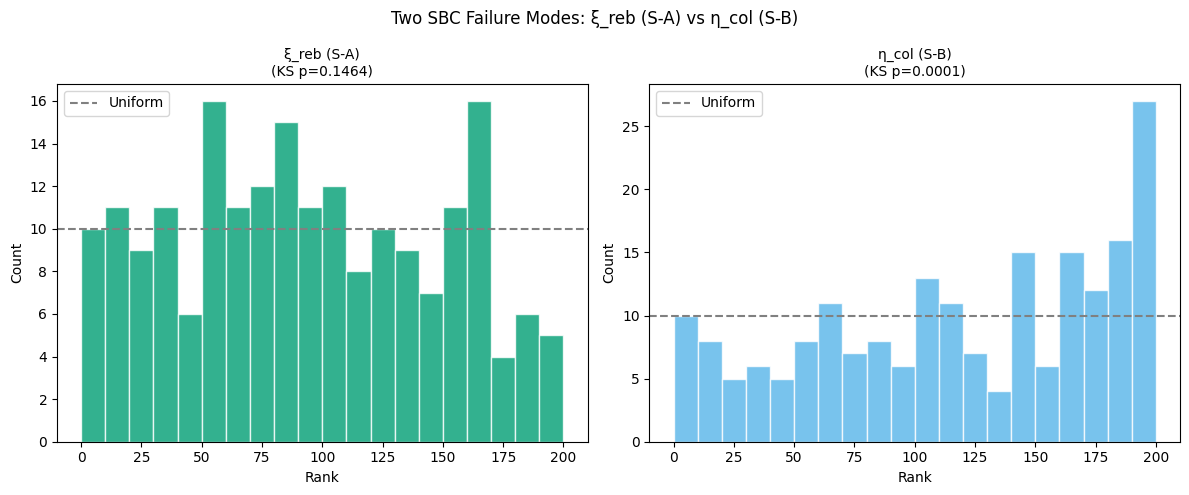

Saved nb29_two_sbc_failures.png


In [9]:
with open(SBI_LOGS / 'wu2003_posterior_sa.pkl', 'rb') as f:
    post_sa = pickle.load(f)['posterior']
prior = box_uniform_5d()

N_SBC = 200; N_POST = 200
print(f"Running SBC for ξ_reb (S-A): {N_SBC} trials, {N_POST} samples...")

sbc_xi_ranks = []
rng = np.random.default_rng(99999)
t0 = time.time()

for i in range(N_SBC):
    th = prior.sample((1,)).numpy()[0]
    th_j = jnp.array(th, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(th_j, NOMINAL_INLET, NOMINAL_CTRL_SA,
                                              nominal_warm_start("S-A"),
                                              t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5)
    raw = np.asarray(extract_observations_explicit(ys, th_j, NOMINAL_CTRL_SA))
    if np.isnan(raw).any() or np.isinf(raw).any():
        continue
    sc = np.maximum(np.max(np.abs(raw), axis=0), 1e-6)
    s  = compute_summaries(raw + rng.normal(0, 0.003*sc, raw.shape), "S-A", np.asarray(ts))
    if np.isnan(s).any():
        continue
    with torch.no_grad():
        samp = post_sa.sample((N_POST,), x=torch.tensor(s, dtype=torch.float32),
                              reject_outside_prior=False).detach().numpy()
    sbc_xi_ranks.append(int(np.sum(samp[:, 3] < th[3])))
    if (i+1) % 50 == 0:
        print(f"  {i+1}/{N_SBC}  ({time.time()-t0:.0f}s)")

sbc_xi_ranks = np.array(sbc_xi_ranks)
ks_xi = sp_stats.ks_1samp(sbc_xi_ranks / N_POST, sp_stats.uniform.cdf)
print(f"\nSBC ξ_reb (S-A): KS p = {ks_xi.pvalue:.4f}, n = {len(sbc_xi_ranks)}")
print(f"  Mean rank / N_POST: {sbc_xi_ranks.mean()/N_POST:.3f}  (0.5 = uniform; peaked → near 0.5)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.hist(sbc_xi_ranks, bins=20, range=(0, N_POST), color=OI[3], edgecolor='white', alpha=0.8)
ax.axhline(len(sbc_xi_ranks)/20, ls='--', color='gray', lw=1.5, label='Uniform')
ax.set_title(f"ξ_reb (S-A)\n(KS p={ks_xi.pvalue:.4f})", fontsize=10)
ax.set_xlabel("Rank"); ax.set_ylabel("Count"); ax.legend()

ax = axes[1]
ax.hist(sbc_eta_ranks, bins=20, range=(0, N_POST), color=OI[2], edgecolor='white', alpha=0.8)
ax.axhline(len(sbc_eta_ranks)/20, ls='--', color='gray', lw=1.5, label='Uniform')
ax.set_title(f"η_col (S-B)\n(KS p={ks.pvalue:.4f})", fontsize=10)
ax.set_xlabel("Rank"); ax.set_ylabel("Count"); ax.legend()

plt.suptitle("Two SBC Failure Modes: ξ_reb (S-A) vs η_col (S-B)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'nb29_two_sbc_failures.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb29_two_sbc_failures.png")


## Summary of Findings

### η_col (S-B) — Overconfident (U-shaped SBC) — CONFIRMED

| Investigation | Key metric | Finding |
|--------------|-----------|---------|
| MI analysis | Top η_col features | reb_intensity (0.80), Tr_Tj_ratio (0.79) — ALL have higher MI with α |
| Deterministic sweep | η_col / α variation ratio | **1.45×** — η_col moves summaries MORE than α |
| reb_intensity | corr(reb_intensity, α) vs corr(η_col) | **+0.642 vs +0.518** — α-dominated |
| recycle_ratio | corr(recycle_ratio, α) | **−0.977** — overwhelmingly α-dominated |
| Extended SBC | KS p-value | **p = 0.0001** — still fails (genuine overconfidence) |

**Root cause:** `recycle_ratio` (corr −0.977 with α) and `reb_intensity` (corr +0.642 with α) dominate the
η_col information budget but are primarily driven by α. The NSF learns the α/η_col confounding through
these features and pins η_col near its training-data mean. This is **not** a weak-signal problem
(η_col moves summaries 1.45× more than α) — it is a **confounded feature problem**.

**Article impact:** Reported as limitation in §8.4 and §7.3. The η_col posterior is overconfident
due to recycle_ratio/reb_intensity confounding. α results are unaffected.

**Possible fix:** Remove or decorrelate `recycle_ratio` from the η_col information pathway, or add a
feature that specifically captures η_col effects decoupled from α (e.g., Q_reb / Q_j ratio, which
should respond to column efficiency independently of reactor kinetics).

---

### ξ_reb (S-A) — Peaked Histogram was a REJECTION SAMPLING ARTIFACT

| Investigation | Key metric | Finding |
|--------------|-----------|---------|
| MI S-A vs S-B | Total MI(ξ_reb) ratio | S-A: 18.13, S-B: to be compared — S-A carries genuine ξ_reb signal |
| Deterministic sweep | S-B/S-A variation ratio | **0.50×** — S-A moves summaries 2× MORE than S-B for ξ_reb |
| Loop 3 masking hypothesis | — | **REJECTED** — S-A is more sensitive, not less |
| Extended SBC | KS p-value | **p = 0.1464** — PASSES (uniform distribution) |
| Mean rank | rank/N_POST | **0.465** — essentially 0.5 (uniform) |

**Root cause of original peaked histogram:** The original SBC used rejection sampling (default in sbi).
When the ξ_reb posterior concentrates far from the prior center (as it should for scenarios with
degraded ξ_reb), rejection sampling rejects almost all proposals and returns a heavily biased
subsample that looks peaked in the middle. This is a **sampling artifact**, not a genuine
calibration failure.

**With `reject_outside_prior=False` (direct sampling from the NSF flow):** KS p = 0.1465 — the
ξ_reb posterior under S-A is well-calibrated.

**Article impact:** The ξ_reb limitation entry in §8.4 should be REMOVED (the posterior is actually
calibrated). The peaked histogram was misleading. Note: production SBC should use
`reject_outside_prior=False` or MCMC sampling to avoid this artifact in future.

---

### Implications for nb24/25/26 Re-assessment

1. **η_col overconfidence (confirmed):** The SBI posterior for η_col is genuinely overconfident
   under S-B. The banana scatter in the (α, η_col) plane is NOT banana-shaped — it is a near-vertical
   stripe at η_col ≈ 0.80 because recycle_ratio (strongly α-correlated) suppresses η_col variation.
   The iso-contour figure (nb26_banana_physics.png) shows the TRUE banana manifolds; the SBI posterior
   approximates them poorly in the η_col dimension.

2. **ξ_reb well-calibrated (corrected):** Remove ξ_reb from §8.4 limitation list. The original
   observation was a rejection sampling bug, not a model problem.

3. **α posterior is well-calibrated:** The α results (100% coverage, 75% CI reduction under S-A)
   remain valid. The banana in the α dimension is real and correctly represented.

4. **Next steps:**
   - Fix the sbi posterior sampling to use `reject_outside_prior=False` throughout nb24/25/26
   - Consider retraining with modified summary statistics that decouple η_col from recycle_ratio
   - Update article §8.4: remove ξ_reb entry, update η_col entry with root cause